In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay, roc_curve, roc_auc_score

import joblib


### Read data

In [2]:
# Read features
dist_data = pd.read_csv('../data/Mateo_2019/selected_structures_unfiltered.tsv', sep='\t')

# Read transcriptional data
transc_data = pd.read_csv('../data/Mateo_2019/transcriptional_data_unfiltered.tsv', sep='\t')

# Merge data
dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='cellNumber').iloc[:, 1:]


### Check data distribution

In [3]:
dist_data

,cellNumber,1-2,1-3,1-4,1-5,1-6,1-7,1-8,1-9,1-10,...,48-49,48-50,48-51,48-52,49-50,49-51,49-52,50-51,50-52,51-52
0,2.0,244.073929,156.705215,227.523438,298.594910,284.360779,319.927277,374.712128,263.243683,307.865479,...,40.655556,158.210205,205.904953,89.207565,190.698318,243.541779,129.752823,129.892990,114.832573,134.459518
1,3.0,262.981628,149.599136,223.714142,298.312103,284.214844,319.122009,373.181580,263.169769,307.152435,...,34.554508,148.777985,164.663910,56.323582,173.666397,188.108734,68.595428,74.033485,109.178902,135.220947
2,4.0,57.026531,114.053062,158.372696,99.316757,381.578186,285.982574,245.477722,143.316086,131.084579,...,47.592033,95.183998,142.776352,134.868652,47.591965,95.184311,87.573639,47.592350,40.972393,14.776049
3,5.0,96.074387,248.331451,431.943512,365.492401,312.008545,323.191193,344.080688,373.049774,408.382874,...,13.840295,27.680204,41.520115,55.360455,13.839910,27.679819,41.520161,13.839910,27.680250,13.840343
4,6.0,62.503872,125.007744,187.511627,77.025963,100.985420,154.911423,217.557861,212.585556,250.578964,...,55.565849,111.131760,129.233322,226.616135,55.565914,113.307808,229.983429,123.090302,246.180954,123.090652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32885,54360.0,102.750069,205.500137,308.250214,411.000397,210.793076,504.672241,322.819763,419.980103,519.280396,...,31.677496,115.259415,608.861206,1105.478760,114.214897,597.610779,1093.241211,496.962738,993.925537,496.962769
32886,54361.0,195.376205,331.793182,311.332672,312.916718,343.966980,439.232422,1014.994324,715.538147,457.085999,...,83.102066,166.204132,209.301727,253.618362,83.102074,138.592422,221.422577,91.762802,218.049500,295.440369
32887,54362.0,84.795517,169.591034,254.386398,387.011017,332.686523,498.608093,822.776733,443.369690,369.567047,...,223.853043,283.546692,574.693970,484.069580,62.116104,796.917725,689.178223,857.717712,749.528992,234.870514
32888,54363.0,45.831791,91.663933,227.901001,305.233826,403.958008,567.012085,793.995728,1044.012451,871.298706,...,30.934589,57.775463,139.123123,133.248871,82.571701,165.143433,149.427689,82.571732,82.203911,69.444191


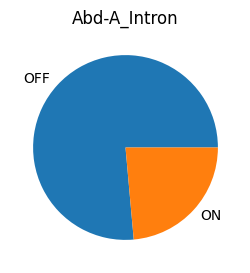

In [4]:
gene_names = transc_data.columns[1:].tolist()

fig, axs = plt.subplots(1, 1, figsize=(3, 3))

for i, gene in enumerate(gene_names):
    axs.pie(dataset[gene].value_counts(), labels=['OFF', 'ON'])
    axs.set_title(f"{gene}")


### Preprocess data

In [5]:
dataset[gene].value_counts()

Abd-A_Intron
0    25136
1     7754
Name: count, dtype: int64

##### Will use data from Abd-A gene, which is the gene yielding best results in paper (1641 OFF vs 653 ON)

In [6]:
dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='cellNumber').iloc[:, 1:]

X = dataset.iloc[:, :-1].to_numpy()
Y = dataset.iloc[:, -1].to_numpy()

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Create model - use grid search for hyperparameter tuning

In [7]:
# Define parameter search
param_grid = {
    'class_weight': ['balanced'],
    'max_depth': [5, 10, 15],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'n_estimators': [100, 150, 200, 300, 400, 500],
}

In [8]:
# Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
# Define model
random_forest_model = RandomForestClassifier(random_state=42)

In [10]:
# Initialize model with grid search
grid_search_random_forest_model = GridSearchCV(estimator=random_forest_model,
                                               param_grid = param_grid,
                                               cv=cv,
                                               scoring='f1_weighted',
                                               n_jobs=-1,
                                               verbose=2)

### Fit model - using entire parameter space

In [11]:
hist = grid_search_random_forest_model.fit(X_train, y_train)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
[CV] END class_weight=balanced, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  27.0s
[CV] END class_weight=balanced, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  27.0s
[CV] END class_weight=balanced, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  27.1s
[CV] END class_weight=balanced, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  27.1s
[CV] END class_weight=balanced, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  27.2s
[CV] END class_weight=balanced, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=  39.4s
[CV] END class_weight=balanced, max_depth=5, max_features=sqrt, min_samples_leaf=1, 

/Users/manfernandez/anaconda3/envs/torch_oligomodeling/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END class_weight=balanced, max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  23.5s
[CV] END class_weight=balanced, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=400; total time= 1.6min
[CV] END class_weight=balanced, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=400; total time= 1.6min
[CV] END class_weight=balanced, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=400; total time= 1.6min
[CV] END class_weight=balanced, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=400; total time= 1.6min
[CV] END class_weight=balanced, max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  24.2s
[CV] END class_weight=balanced, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=400; total time= 1.6min
[

KeyboardInterrupt: 

### Save hyperparameter tuning results

In [ ]:
joblib.dump(grid_search_random_forest_model, "../results/random_forest_Mateo/gridsearch_results_random_forest_unfiltered.pkl")

grid_search_df = pd.DataFrame(grid_search_random_forest_model.cv_results_)
grid_search_df.to_csv("../results/random_forest_Mateo/gridsearch_results_random_forest_unfiltered.tsv", index=False, sep='\t')

In [ ]:
print('The best hyperparameters found using 5-fold cross-validation are:')
print(grid_search_random_forest_model.best_params_)

with open('../results/random_forest_Mateo/hyperparams_unfiltered.txt', 'w') as f:
    f.write('The best hyperparameters found using 5-fold cross-validation are:\n')
    for key in grid_search_random_forest_model.best_params_:
        f.write(f"{key}: {grid_search_random_forest_model.best_params_[key]}\n")

The best hyperparameters found using 5-fold cross-validation are:
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


### Calculate predictions and plot metrics

In [ ]:
# Select best model
best_model = grid_search_random_forest_model.best_estimator_

# Calculate predictions
y_pred = best_model.predict(X_test)
y_pred_scores = best_model.predict_proba(X_test)[:,1]

# Calculate predictions on training dataset
y_pred_train = best_model.predict(X_train)
y_pred_train_scores = best_model.predict_proba(X_train)[:,1]


In [ ]:
# Classification report
class_report = classification_report(y_test, y_pred)

# Confusion matrics
conf_matrix = confusion_matrix(y_test, y_pred)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_scores)
auc = roc_auc_score(y_test, y_pred_scores)

# training ROC
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_pred_train_scores)
auc_train = roc_auc_score(y_train, y_pred_train_scores)

In [ ]:
# Print classification report
print(class_report)

with open('../results/random_forest_Mateo/classification_report_unfiltered.txt', 'w') as f:
    f.write(class_report)

              precision    recall  f1-score   support

           0       0.81      0.82      0.81       328
           1       0.53      0.53      0.53       131

    accuracy                           0.73       459
   macro avg       0.67      0.67      0.67       459
weighted avg       0.73      0.73      0.73       459



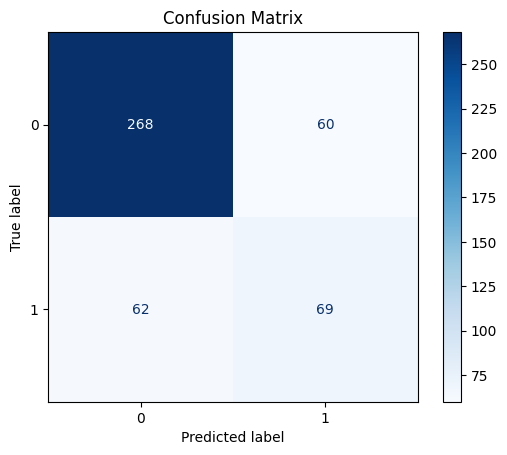

In [ ]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest_Mateo/confusion_matrix_unfiltered.pdf', format='pdf')

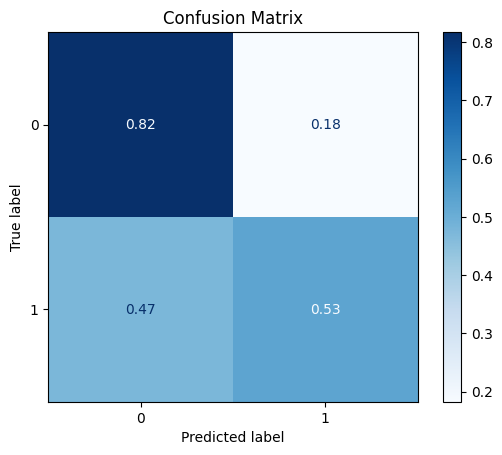

In [ ]:
# Normalized confusion matrix
cm_norm = conf_matrix.astype(float) / conf_matrix.sum(axis=1)[:, None]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest_Mateo/confusion_matrix_normalized_unfiltered.pdf', format='pdf')

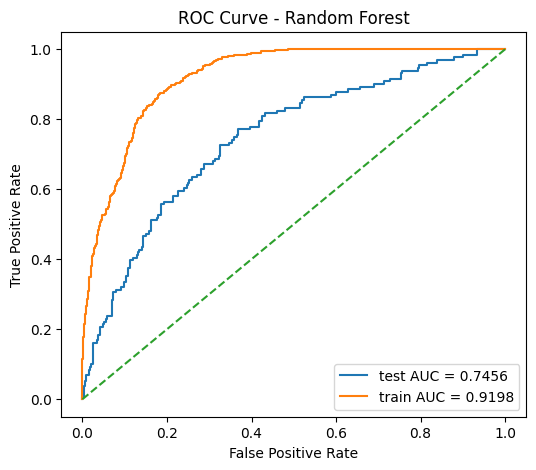

In [ ]:
# ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"test AUC = {auc:.4f}")
plt.plot(fpr_train, tpr_train, label=f"train AUC = {auc_train:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.savefig('../results/random_forest_Mateo/ROC_unfiltered.pdf', format='pdf')

In [ ]:
# Get feture importances
n_feats = 20
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:n_feats]
features = dataset.columns[:-1]

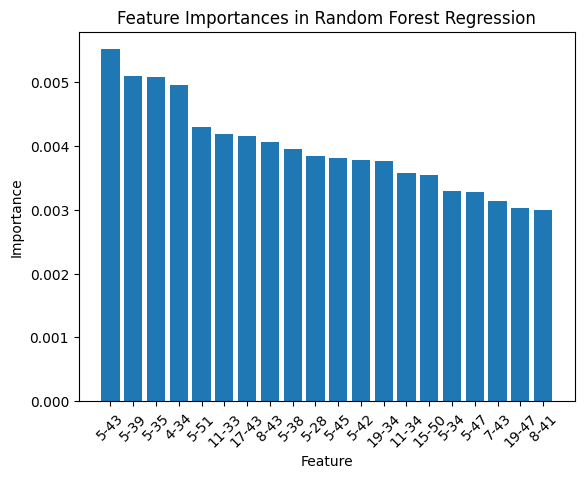

In [ ]:
# Plot feature importances
plt.bar(range(n_feats), importances[indices],  align="center")
plt.xticks(range(n_feats), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")

plt.savefig('../results/random_forest_Mateo/feature_importance_unfiltered.pdf', format='pdf')